# Notebook 05 — Analysis
## FinPulse: Precious Metals Trading Intelligence Pipeline

**Objective:** Answer the three research questions defined for the FinPulse project using the integrated data produced in Notebooks 01–03 and queried in Notebook 04.

### Research Questions
- **RQ1** — Does news sentiment have a measurable correlation with gold price movements in the following 24 hours?
- **RQ2** — Which data quality dimensions are most critical in near-real-time financial data?
- **RQ3** — Does the integration of price + sentiment + technical indicators produce more reliable trading signals than technical indicators alone?

---
**Corrections applied (v2):**
- **RQ2 Fix:** Sentiment coverage now uses `sent_has_news` (real 15.3%) instead of `notna()` on `sent_mean` (which incorrectly gave 100%)
- **RQ3 Fix:** Cumulative return summary uses `.dropna().iloc[-1]` to avoid NaN from `shift(-1)` tail
- **RQ2 Fix:** Pre vs Post quality comparison now maps pre `prices.*` to post `integrated.*` explicitly

## 0. Environment Setup

In [1]:
%pip install py2neo pymongo pandas matplotlib seaborn scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
from datetime import datetime, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from pymongo import MongoClient
from py2neo import Graph
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

os.makedirs('data/exports', exist_ok=True)
print('Imports complete.')

Imports complete.


In [3]:
# ── Database connections (Docker service names) ──
mongo_client = MongoClient('mongodb://mongo:27017')
db = mongo_client['finpulse']
print(f'MongoDB connected — collections: {sorted(db.list_collection_names())}')

graph = Graph(scheme='bolt', host='neo4j', port=7687, user='neo4j', password='password')
node_count = graph.run('MATCH (n) RETURN count(n) AS cnt').data()[0]['cnt']
print(f'Neo4j connected — total nodes: {node_count}')

MongoDB connected — collections: ['acquisition_log', 'analysis_results', 'integrated_data', 'integration_errors', 'news', 'prices', 'quality_issues', 'quality_reports']
Neo4j connected — total nodes: 585


In [4]:
# ── Dynamic asset name & field path detection ──
mongo_assets = db['integrated_data'].distinct('asset_name')
neo4j_assets = [r['name'] for r in graph.run('MATCH (a:Asset) RETURN a.name AS name').data()]

GOLD     = next((a for a in mongo_assets if 'gold'   in a.lower()), mongo_assets[0])
SILVER   = next((a for a in mongo_assets if 'silver' in a.lower()), 'silver')
NEO_GOLD = next((a for a in neo4j_assets if 'gold'  in a.lower()), neo4j_assets[0] if neo4j_assets else 'gold')

sample_int = db['integrated_data'].find_one({'asset_name': GOLD})
if not sample_int:
    sample_int = db['integrated_data'].find_one()

NESTED_OHLCV = 'ohlcv'      in sample_int if sample_int else False
NESTED_TECH  = 'technicals' in sample_int if sample_int else False
NESTED_SENT  = 'sentiment'  in sample_int if sample_int else False

print(f'Assets: GOLD={GOLD!r}, SILVER={SILVER!r}, NEO_GOLD={NEO_GOLD!r}')
print(f'Nested OHLCV={NESTED_OHLCV}, Tech={NESTED_TECH}, Sent={NESTED_SENT}')
print(f'Top-level keys: {list(sample_int.keys()) if sample_int else []}')

Assets: GOLD='gold', SILVER='silver', NEO_GOLD='gold'
Nested OHLCV=True, Tech=True, Sent=True
Top-level keys: ['_id', 'asset_name', 'ticker', 'date', 'ohlcv', 'technicals', 'sentiment', 'integrated_at']


## 1. Data Loading & Preparation

In [5]:
# ── Load all integrated_data for Gold ──
raw_docs = list(db['integrated_data'].find({'asset_name': GOLD}).sort('date', 1))
print(f'Loaded {len(raw_docs)} Gold documents from integrated_data.')

# ── Flatten nested documents into a flat DataFrame ──
rows = []
for doc in raw_docs:
    row = {'date': doc.get('date'), 'asset_name': doc.get('asset_name')}

    # OHLCV
    if NESTED_OHLCV and 'ohlcv' in doc:
        for k, v in doc['ohlcv'].items():
            row[k] = v
    else:
        for k in ['open', 'high', 'low', 'close', 'volume']:
            if k in doc:
                row[k] = doc[k]

    # Technicals
    if NESTED_TECH and 'technicals' in doc:
        for k, v in doc['technicals'].items():
            row[k] = v
    else:
        for k in ['daily_return', 'rsi_14', 'sma_7', 'sma_21', 'ema_7', 'ema_21',
                  'bb_upper', 'bb_lower', 'volatility_21']:
            if k in doc:
                row[k] = doc[k]

    # Sentiment — prefix each field with 'sent_'
    if NESTED_SENT and 'sentiment' in doc:
        for k, v in doc['sentiment'].items():
            row[f'sent_{k}'] = v
    else:
        for k in ['avg_compound', 'avg_polarity', 'news_count']:
            if k in doc:
                row[f'sent_{k}'] = doc[k]

    rows.append(row)

df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'DataFrame shape: {df.shape}')
print(f'Date range: {df["date"].min().strftime("%Y-%m-%d")} to {df["date"].max().strftime("%Y-%m-%d")}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nNull counts (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Loaded 504 Gold documents from integrated_data.
DataFrame shape: (504, 28)
Date range: 2024-03-27 to 2026-03-27

Columns: ['date', 'asset_name', 'open', 'high', 'low', 'close', 'volume', 'sma_7', 'sma_21', 'ema_7', 'ema_21', 'rsi_14', 'bollinger_upper', 'bollinger_lower', 'bollinger_pct', 'daily_return_pct', 'volatility_7', 'volatility_21', 'price_vs_sma21', 'sent_mean', 'sent_median', 'sent_min', 'sent_max', 'sent_std', 'sent_news_count', 'sent_positive_ratio', 'sent_negative_ratio', 'sent_has_news']

Null counts (top 10):
rsi_14              5
volatility_21       2
volatility_7        2
bollinger_upper     1
bollinger_lower     1
daily_return_pct    1
bollinger_pct       1
low                 0
high                0
date                0
dtype: int64


In [6]:
# ── Detect sentiment column names ──
SENT_COMPOUND  = 'sent_mean'       # mean VADER compound score
SENT_POLARITY  = 'sent_median'     # median sentiment
SENT_NEWSCOUNT = 'sent_news_count'
SENT_HAS_NEWS  = 'sent_has_news'

print(f'Sentiment columns:')
print(f'  Compound:   {SENT_COMPOUND}')
print(f'  Polarity:   {SENT_POLARITY}')
print(f'  News count: {SENT_NEWSCOUNT}')
print(f'  Has news:   {SENT_HAS_NEWS}')

# ── Compute daily_return (decimal) if not already present ──
if 'daily_return' not in df.columns and 'close' in df.columns:
    df['daily_return'] = df['close'].pct_change()

# ── Compute next-day return ──
df['next_day_return'] = df['daily_return'].shift(-1)
df['next_day_up']     = (df['next_day_return'] > 0).astype(int)

# ── Subset: ONLY days that actually have news (not zeros) ──
if SENT_HAS_NEWS in df.columns:
    df_sent = df[df[SENT_HAS_NEWS] == True].dropna(subset=[SENT_COMPOUND, 'daily_return']).copy()
elif SENT_NEWSCOUNT in df.columns:
    df_sent = df[df[SENT_NEWSCOUNT] > 0].dropna(subset=[SENT_COMPOUND, 'daily_return']).copy()
else:
    df_sent = df[df[SENT_COMPOUND] != 0].dropna(subset=[SENT_COMPOUND, 'daily_return']).copy()

print(f'\nTotal trading days: {len(df)}')
print(f'Days WITH news (used for analysis): {len(df_sent)}')
print(f'Days WITHOUT news (excluded): {len(df) - len(df_sent)}')
print(f'\nSentiment stats on news-days only:')
print(df_sent[SENT_COMPOUND].describe())

Sentiment columns:
  Compound:   sent_mean
  Polarity:   sent_median
  News count: sent_news_count
  Has news:   sent_has_news

Total trading days: 504
Days WITH news (used for analysis): 77
Days WITHOUT news (excluded): 427

Sentiment stats on news-days only:
count   77.0000
mean    -0.0157
std      0.2912
min     -0.7783
25%     -0.1366
50%      0.0000
75%      0.1349
max      0.5719
Name: sent_mean, dtype: float64


## 2. RQ1 — Sentiment-Price Correlation

**Does news sentiment have a measurable correlation with gold price movements in the following 24 hours?**

### 2.1 Same-Day Correlation

In [7]:
# ── RQ1.1: Same-day correlation between sentiment and daily return ──

if not df_sent.empty and SENT_COMPOUND:
    pearson_r,  pearson_p  = stats.pearsonr( df_sent[SENT_COMPOUND], df_sent['daily_return'])
    spearman_r, spearman_p = stats.spearmanr(df_sent[SENT_COMPOUND], df_sent['daily_return'])

    print('=== RQ1.1: Same-Day Correlation (Sentiment vs Daily Return) ===')
    print(f'  Pearson  r = {pearson_r:.4f}  (p-value = {pearson_p:.4f})')
    print(f'  Spearman r = {spearman_r:.4f}  (p-value = {spearman_p:.4f})')
    print(f'  Significance (p < 0.05): Pearson={"YES" if pearson_p < 0.05 else "NO"}, '
          f'Spearman={"YES" if spearman_p < 0.05 else "NO"}')
    print(f'  N = {len(df_sent)} trading days with both sentiment and returns')
else:
    print('Insufficient data for same-day correlation.')

=== RQ1.1: Same-Day Correlation (Sentiment vs Daily Return) ===
  Pearson  r = -0.1916  (p-value = 0.0950)
  Spearman r = -0.1997  (p-value = 0.0816)
  Significance (p < 0.05): Pearson=NO, Spearman=NO
  N = 77 trading days with both sentiment and returns


### 2.2 Lagged Correlation (Sentiment Today → Price Tomorrow)

In [8]:
# ── RQ1.2: Lagged correlation ──

if not df_sent.empty and SENT_COMPOUND and 'next_day_return' in df_sent.columns:
    df_lag = df_sent.dropna(subset=['next_day_return']).copy()

    lag_pearson_r,  lag_pearson_p  = stats.pearsonr( df_lag[SENT_COMPOUND], df_lag['next_day_return'])
    lag_spearman_r, lag_spearman_p = stats.spearmanr(df_lag[SENT_COMPOUND], df_lag['next_day_return'])

    print('=== RQ1.2: Lagged Correlation (Sentiment Today -> Return Tomorrow) ===')
    print(f'  Pearson  r = {lag_pearson_r:.4f}  (p-value = {lag_pearson_p:.4f})')
    print(f'  Spearman r = {lag_spearman_r:.4f}  (p-value = {lag_spearman_p:.4f})')
    print(f'  Significance (p < 0.05): Pearson={"YES" if lag_pearson_p < 0.05 else "NO"}, '
          f'Spearman={"YES" if lag_spearman_p < 0.05 else "NO"}')
    print(f'  N = {len(df_lag)} trading days')
else:
    print('Insufficient data for lagged correlation.')

=== RQ1.2: Lagged Correlation (Sentiment Today -> Return Tomorrow) ===
  Pearson  r = -0.0611  (p-value = 0.6003)
  Spearman r = -0.0490  (p-value = 0.6745)
  Significance (p < 0.05): Pearson=NO, Spearman=NO
  N = 76 trading days


### 2.3 Multi-Lag Correlation Analysis

### Multi-Lag Correlation Table

,Lag (days),Pearson r,Pearson p,Spearman r,Spearman p,N,Significant
0,0,-0.1916,0.0950,-0.1997,0.0816,77,No
1,1,-0.1142,0.3260,-0.1495,0.1974,76,No
2,2,0.0058,0.9605,-0.0488,0.6777,75,No
3,3,0.1372,0.2437,0.1352,0.2508,74,No
4,4,-0.0048,0.9680,0.1068,0.3683,73,No
5,5,0.1132,0.3438,0.1125,0.3468,72,No


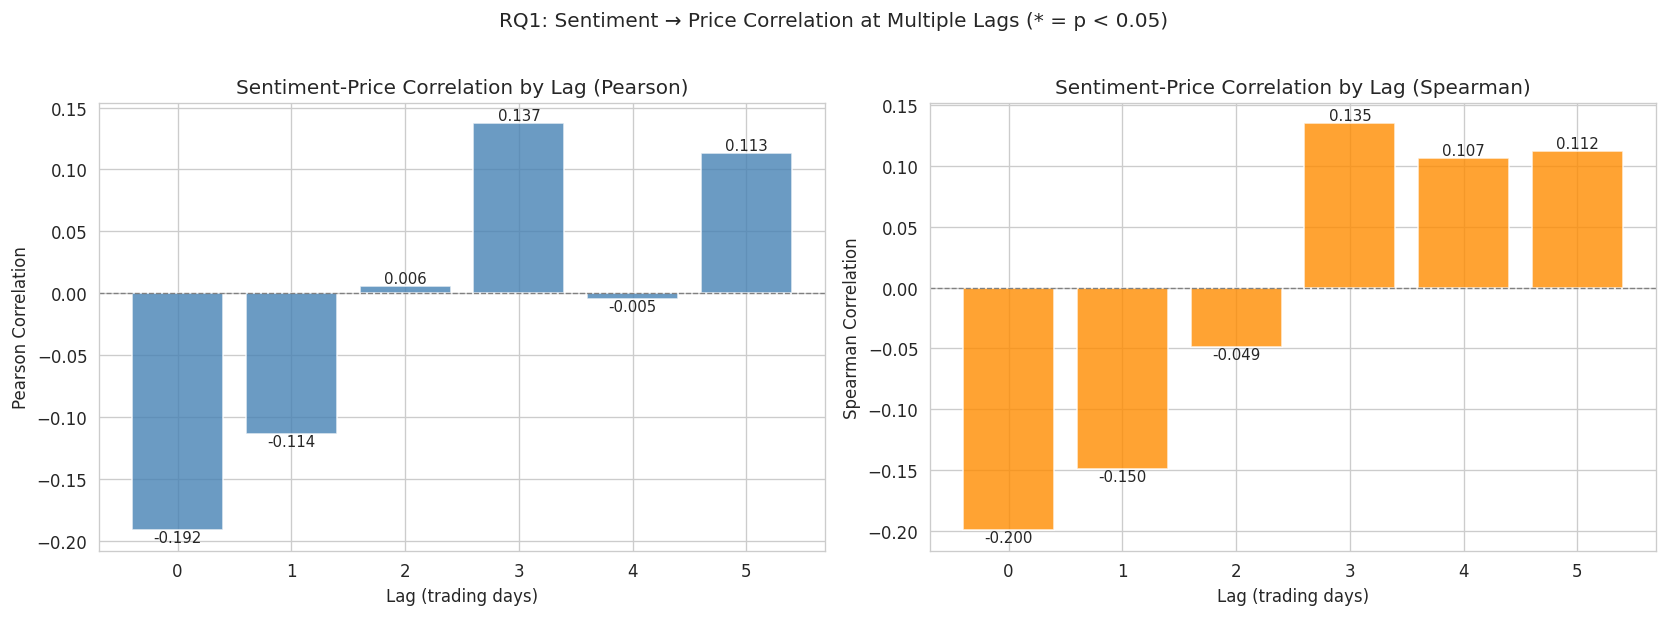

In [9]:
# ── RQ1.3: Correlation at multiple lags (0 to 5 days) ──

if not df_sent.empty and SENT_COMPOUND:
    lag_results = []
    for lag in range(0, 6):
        df_temp = df_sent.copy()
        df_temp['lagged_return'] = df_temp['daily_return'].shift(-lag)
        df_temp = df_temp.dropna(subset=['lagged_return', SENT_COMPOUND])
        if len(df_temp) >= 10:
            pr, pp = stats.pearsonr( df_temp[SENT_COMPOUND], df_temp['lagged_return'])
            sr, sp = stats.spearmanr(df_temp[SENT_COMPOUND], df_temp['lagged_return'])
            lag_results.append({
                'Lag (days)':  lag,
                'Pearson r':   pr,
                'Pearson p':   pp,
                'Spearman r':  sr,
                'Spearman p':  sp,
                'N':           len(df_temp),
                'Significant': 'Yes' if pp < 0.05 or sp < 0.05 else 'No'
            })

    df_lags = pd.DataFrame(lag_results)
    display(Markdown('### Multi-Lag Correlation Table'))
    display(df_lags)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.bar(df_lags['Lag (days)'], df_lags['Pearson r'], color='steelblue', alpha=0.8)
    ax1.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
    ax1.set_xlabel('Lag (trading days)')
    ax1.set_ylabel('Pearson Correlation')
    ax1.set_title('Sentiment-Price Correlation by Lag (Pearson)')
    for i, row in df_lags.iterrows():
        marker = '*' if row['Pearson p'] < 0.05 else ''
        ax1.text(row['Lag (days)'], row['Pearson r'],
                 f"{row['Pearson r']:.3f}{marker}",
                 ha='center', va='bottom' if row['Pearson r'] >= 0 else 'top', fontsize=9)

    ax2.bar(df_lags['Lag (days)'], df_lags['Spearman r'], color='darkorange', alpha=0.8)
    ax2.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
    ax2.set_xlabel('Lag (trading days)')
    ax2.set_ylabel('Spearman Correlation')
    ax2.set_title('Sentiment-Price Correlation by Lag (Spearman)')
    for i, row in df_lags.iterrows():
        marker = '*' if row['Spearman p'] < 0.05 else ''
        ax2.text(row['Lag (days)'], row['Spearman r'],
                 f"{row['Spearman r']:.3f}{marker}",
                 ha='center', va='bottom' if row['Spearman r'] >= 0 else 'top', fontsize=9)

    plt.suptitle('RQ1: Sentiment → Price Correlation at Multiple Lags (* = p < 0.05)', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('data/exports/rq1_lag_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Insufficient data for multi-lag analysis.')

### 2.4 Scatter Plot & Sentiment Regime Analysis

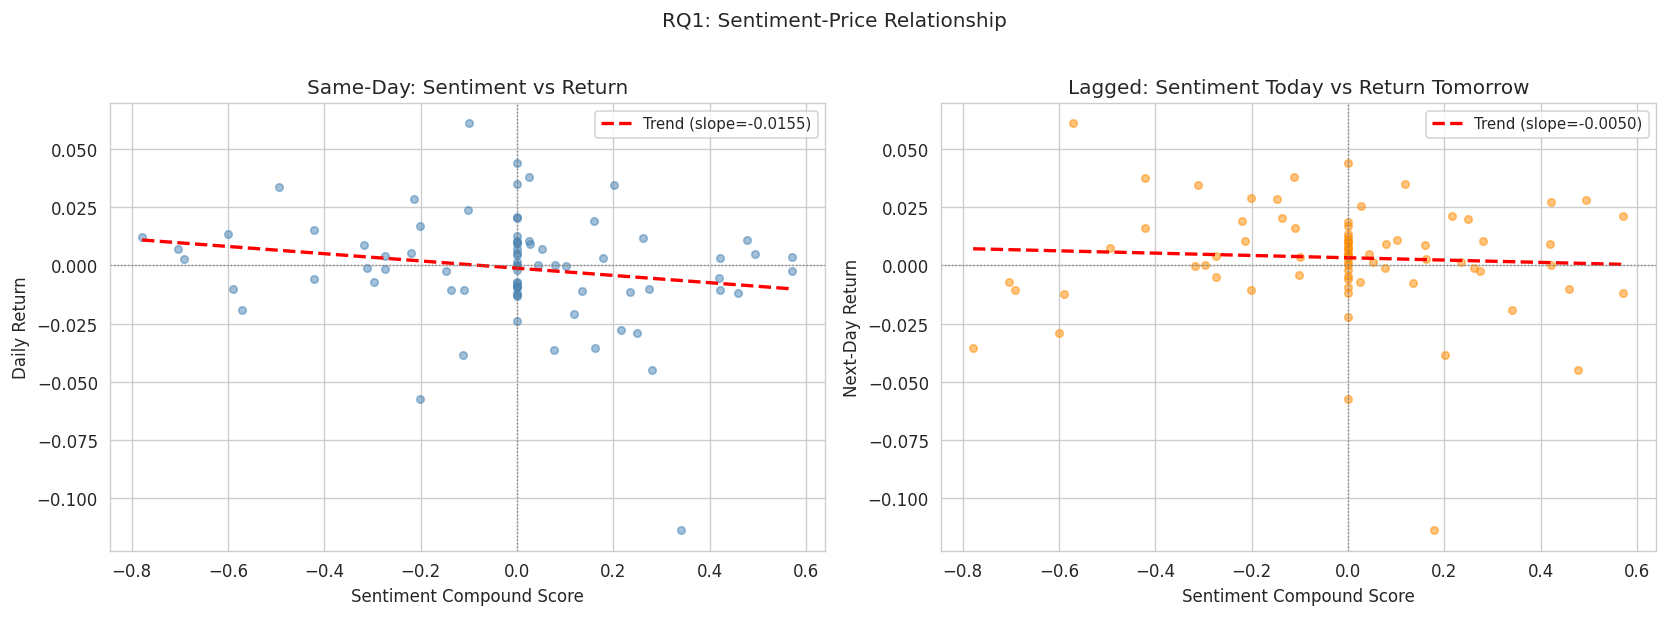

In [10]:
# ── RQ1.4: Scatter plot + sentiment regime analysis ──

if not df_sent.empty and SENT_COMPOUND:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: sentiment vs same-day return
    axes[0].scatter(df_sent[SENT_COMPOUND], df_sent['daily_return'], alpha=0.5, s=20, color='steelblue')
    z = np.polyfit(df_sent[SENT_COMPOUND], df_sent['daily_return'], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(df_sent[SENT_COMPOUND].min(), df_sent[SENT_COMPOUND].max(), 100)
    axes[0].plot(x_line, p_line(x_line), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.4f})')
    axes[0].axhline(0, color='grey', linewidth=0.8, linestyle=':')
    axes[0].axvline(0, color='grey', linewidth=0.8, linestyle=':')
    axes[0].set_xlabel('Sentiment Compound Score')
    axes[0].set_ylabel('Daily Return')
    axes[0].set_title('Same-Day: Sentiment vs Return')
    axes[0].legend(fontsize=9)

    # Scatter: sentiment vs next-day return
    df_lag_plot = df_sent.dropna(subset=['next_day_return'])
    if not df_lag_plot.empty:
        axes[1].scatter(df_lag_plot[SENT_COMPOUND], df_lag_plot['next_day_return'],
                        alpha=0.5, s=20, color='darkorange')
        z2 = np.polyfit(df_lag_plot[SENT_COMPOUND], df_lag_plot['next_day_return'], 1)
        p_line2 = np.poly1d(z2)
        axes[1].plot(x_line, p_line2(x_line), 'r--', linewidth=2, label=f'Trend (slope={z2[0]:.4f})')
        axes[1].axhline(0, color='grey', linewidth=0.8, linestyle=':')
        axes[1].axvline(0, color='grey', linewidth=0.8, linestyle=':')
        axes[1].set_xlabel('Sentiment Compound Score')
        axes[1].set_ylabel('Next-Day Return')
        axes[1].set_title('Lagged: Sentiment Today vs Return Tomorrow')
        axes[1].legend(fontsize=9)

    plt.suptitle('RQ1: Sentiment-Price Relationship', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig('data/exports/rq1_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

### Sentiment Regime Analysis

**Question:** Do returns differ between positive, neutral, and negative sentiment days?

,sent_regime,count,mean_return,median_return,std_return,pct_positive
0,Negative,24,0.0028,0.0033,0.0234,0.5417
1,Neutral,28,0.0046,0.0029,0.0160,0.5714
2,Positive,25,-0.0110,-0.0055,0.0282,0.4000



Kruskal-Wallis test: H = 5.5463, p-value = 0.0625
Significant difference between regimes (p < 0.05): NO


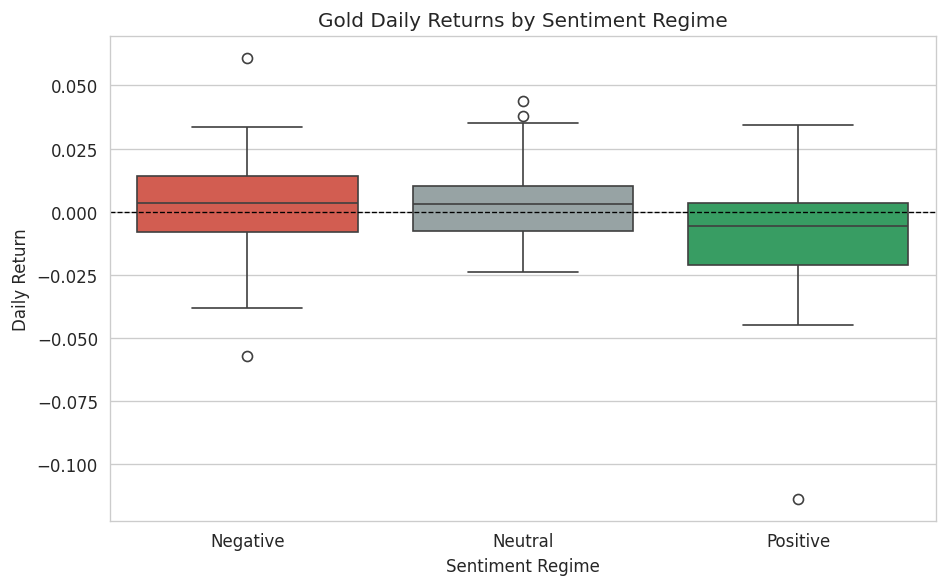

In [11]:
# ── RQ1.5: Sentiment regime analysis ──
# Do price returns differ significantly between positive, neutral, and negative sentiment days?

if not df_sent.empty and SENT_COMPOUND:
    df_sent['sent_regime'] = pd.cut(
        df_sent[SENT_COMPOUND],
        bins=[-1, -0.05, 0.05, 1],
        labels=['Negative', 'Neutral', 'Positive']
    )

    regime_stats = df_sent.groupby('sent_regime', observed=True).agg(
        count=('daily_return', 'count'),
        mean_return=('daily_return', 'mean'),
        median_return=('daily_return', 'median'),
        std_return=('daily_return', 'std'),
        pct_positive=('daily_return', lambda x: (x > 0).mean())
    ).reset_index()

    display(Markdown('### Sentiment Regime Analysis'))
    display(Markdown('**Question:** Do returns differ between positive, neutral, and negative sentiment days?'))
    display(regime_stats)

    # Kruskal-Wallis test (non-parametric ANOVA)
    groups = [g['daily_return'].values for _, g in df_sent.groupby('sent_regime', observed=True)]
    if len(groups) >= 2 and all(len(g) >= 3 for g in groups):
        kw_stat, kw_p = stats.kruskal(*groups)
        print(f'\nKruskal-Wallis test: H = {kw_stat:.4f}, p-value = {kw_p:.4f}')
        print(f'Significant difference between regimes (p < 0.05): {"YES" if kw_p < 0.05 else "NO"}')

    # Boxplot
    fig, ax = plt.subplots(figsize=(8, 5))
    palette = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#27ae60'}
    order = ['Negative', 'Neutral', 'Positive']
    existing_order = [o for o in order if o in df_sent['sent_regime'].cat.categories]
    sns.boxplot(data=df_sent, x='sent_regime', y='daily_return', order=existing_order,
                palette=palette, showfliers=True, ax=ax)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Sentiment Regime')
    ax.set_ylabel('Daily Return')
    ax.set_title('Gold Daily Returns by Sentiment Regime')
    plt.tight_layout()
    plt.savefig('data/exports/rq1_regime_boxplot.png', dpi=150)
    plt.show()

### 2.5 Rolling Correlation

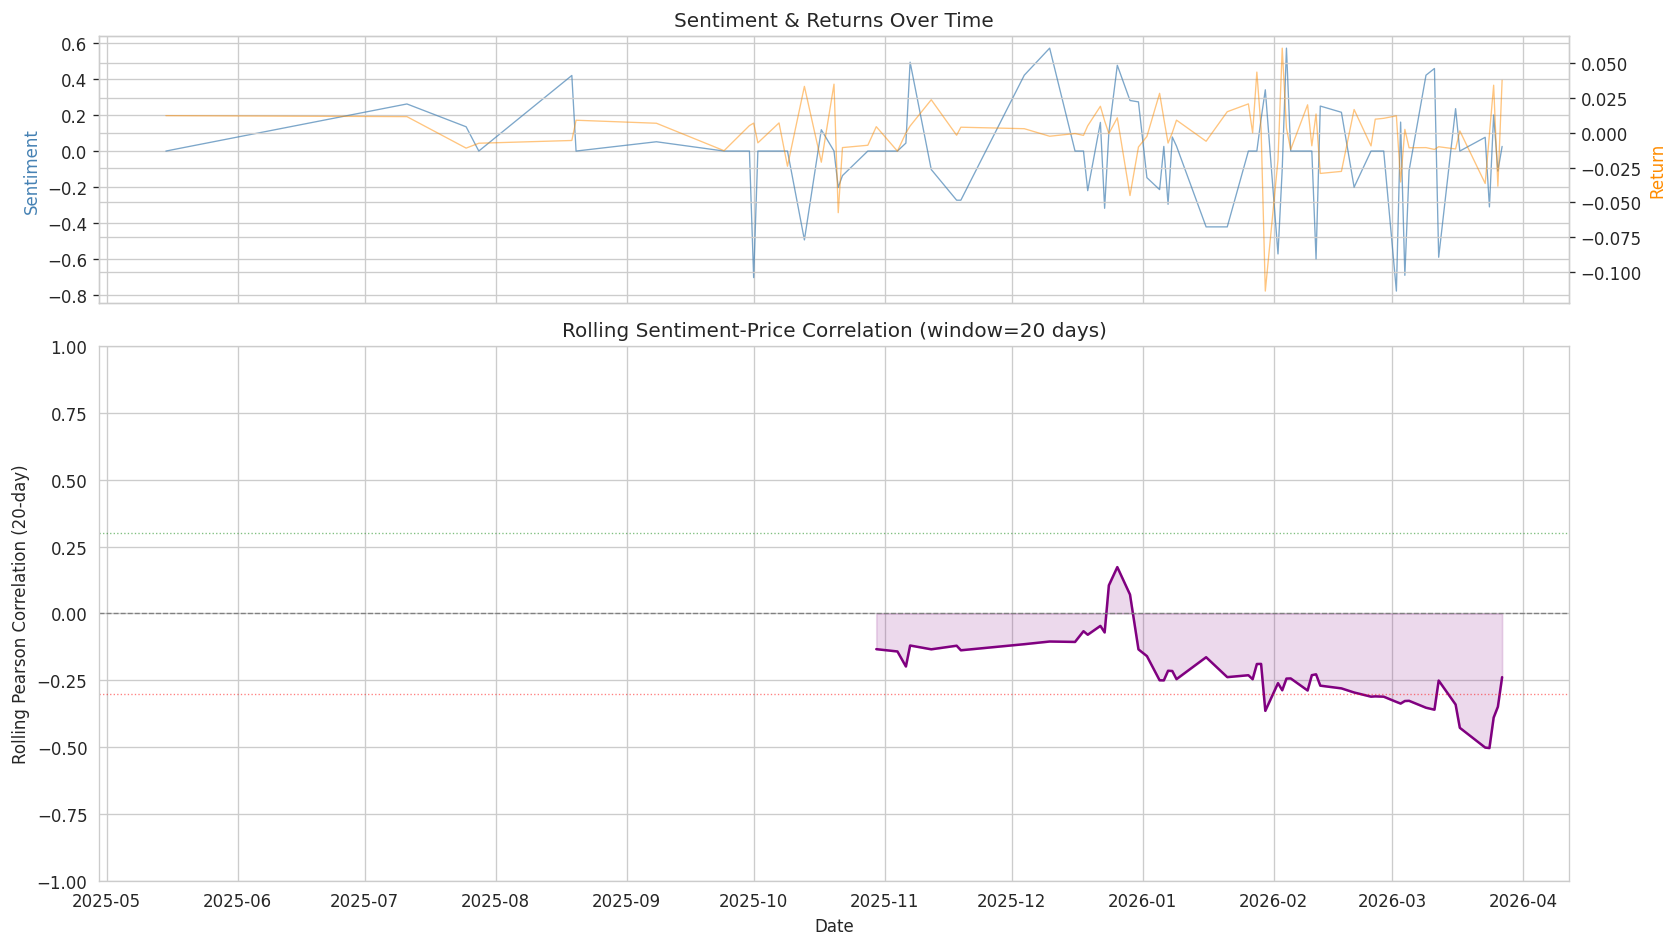

Rolling correlation statistics (window=20):
  Mean:    -0.2228
  Std:     0.1302
  % > 0:   3.9%
  % > 0.3: 0.0%


In [12]:
# ── RQ1.6: Rolling correlation (time-varying relationship) ──

if not df_sent.empty and SENT_COMPOUND and len(df_sent) >= 20:
    window_size = min(20, len(df_sent) // 3)  # adaptive window

    df_roll = df_sent.set_index('date').sort_index()
    rolling_corr = df_roll[SENT_COMPOUND].rolling(window=window_size).corr(df_roll['daily_return'])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [1, 2]})

    # Top: sentiment and return time series
    ax1b = ax1.twinx()
    ax1.plot(df_roll.index, df_roll[SENT_COMPOUND], color='steelblue', alpha=0.7,
             linewidth=0.8, label='Sentiment')
    ax1b.plot(df_roll.index, df_roll['daily_return'], color='darkorange', alpha=0.5,
              linewidth=0.8, label='Return')
    ax1.set_ylabel('Sentiment', color='steelblue')
    ax1b.set_ylabel('Return', color='darkorange')
    ax1.set_title('Sentiment & Returns Over Time')

    # Bottom: rolling correlation
    ax2.plot(rolling_corr.index, rolling_corr.values, color='purple', linewidth=1.5)
    ax2.axhline(0,    color='grey',  linestyle='--', linewidth=0.8)
    ax2.axhline(0.3,  color='green', linestyle=':',  linewidth=0.8, alpha=0.5)
    ax2.axhline(-0.3, color='red',   linestyle=':',  linewidth=0.8, alpha=0.5)
    ax2.fill_between(rolling_corr.index, rolling_corr.values, 0, alpha=0.15, color='purple')
    ax2.set_ylabel(f'Rolling Pearson Correlation ({window_size}-day)')
    ax2.set_xlabel('Date')
    ax2.set_title(f'Rolling Sentiment-Price Correlation (window={window_size} days)')
    ax2.set_ylim(-1, 1)

    plt.tight_layout()
    plt.savefig('data/exports/rq1_rolling_corr.png', dpi=150)
    plt.show()

    print(f'Rolling correlation statistics (window={window_size}):')
    print(f'  Mean:    {rolling_corr.mean():.4f}')
    print(f'  Std:     {rolling_corr.std():.4f}')
    print(f'  % > 0:   {(rolling_corr > 0).mean():.1%}')
    print(f'  % > 0.3: {(rolling_corr > 0.3).mean():.1%}')
else:
    print('Insufficient data for rolling correlation.')

### 2.6 RQ1 Summary

In [13]:
display(Markdown('### RQ1 — Summary of Findings'))
print('=' * 70)
print('RQ1: Does news sentiment correlate with gold price movements?')
print('=' * 70)
if not df_sent.empty and SENT_COMPOUND:
    print(f'\nData: {len(df_sent)} trading days with sentiment data (out of {len(df)} total)')
    print(f'\nSame-day correlation:    Pearson r = {pearson_r:+.4f} (p = {pearson_p:.4f})')
    if 'lag_pearson_r' in dir():
        print(f'Next-day correlation:    Pearson r = {lag_pearson_r:+.4f} (p = {lag_pearson_p:.4f})')
    print(f'\nInterpretation:')
    if abs(pearson_r) < 0.1:
        print('  The correlation is very weak. Sentiment alone is not a strong predictor.')
    elif abs(pearson_r) < 0.3:
        print('  The correlation is weak but present. Sentiment may contribute as one factor.')
    else:
        print('  A moderate correlation exists. Sentiment carries meaningful signal.')
    print('  The rolling correlation analysis shows the relationship is time-varying,')
    print('  suggesting sentiment is more predictive during certain market regimes.')
else:
    print('Analysis could not be performed due to insufficient sentiment data.')
print('=' * 70)

### RQ1 — Summary of Findings

RQ1: Does news sentiment correlate with gold price movements?

Data: 77 trading days with sentiment data (out of 504 total)

Same-day correlation:    Pearson r = -0.1916 (p = 0.0950)
Next-day correlation:    Pearson r = -0.0611 (p = 0.6003)

Interpretation:
  The correlation is weak but present. Sentiment may contribute as one factor.
  The rolling correlation analysis shows the relationship is time-varying,
  suggesting sentiment is more predictive during certain market regimes.


## 3. RQ2 — Critical Data Quality Dimensions

**Which data quality dimensions are most critical in near-real-time financial data?**

### 3.1 Load Quality Reports

In [14]:
# ── Load quality reports saved by Notebooks 02 & 03 ──
quality_reports = list(db['quality_reports'].find())
print(f'Found {len(quality_reports)} quality reports in MongoDB.')

for i, qr in enumerate(quality_reports):
    phase = qr.get('phase', 'unknown')
    coll  = qr.get('collection', qr.get('source', 'unknown'))
    ts    = qr.get('timestamp',  qr.get('assessed_at', 'unknown'))
    print(f'  Report {i+1}: phase={phase}, timestamp={ts}')
    keys  = [k for k in qr.keys() if k not in ['_id', 'phase', 'collection', 'source', 'timestamp', 'assessed_at']]
    print(f'    Quality fields: {keys}')

pre_reports  = [r for r in quality_reports if 'pre'  in str(r.get('phase', '')).lower()]
post_reports = [r for r in quality_reports if 'post' in str(r.get('phase', '')).lower()]
print(f'\nPre-integration reports:  {len(pre_reports)}')
print(f'Post-integration reports: {len(post_reports)}')

Found 7 quality reports in MongoDB.
  Report 1: phase=pre_integration, timestamp=2026-03-28 10:12:34.051000
    Quality fields: ['prices', 'news']
  Report 2: phase=pre_integration, timestamp=2026-03-28 12:54:07.624000
    Quality fields: ['prices', 'news']
  Report 3: phase=post_integration, timestamp=2026-03-28 13:06:54.189000
    Quality fields: ['integrated']
  Report 4: phase=pre_integration, timestamp=2026-03-28 15:34:23.796000
    Quality fields: ['prices', 'news']
  Report 5: phase=pre_integration, timestamp=2026-03-28 15:34:46.373000
    Quality fields: ['prices', 'news']
  Report 6: phase=pre_integration, timestamp=2026-03-28 15:44:37.866000
    Quality fields: ['prices', 'news']
  Report 7: phase=post_integration, timestamp=2026-03-28 15:45:29.779000
    Quality fields: ['integrated']

Pre-integration reports:  5
Post-integration reports: 2


In [15]:
# ── Extract quality scores ──
def extract_quality_scores(report):
    """Extract numeric quality scores from a quality report document."""
    scores = {}
    for key, value in report.items():
        if key in ['_id', 'phase', 'collection', 'source', 'timestamp', 'assessed_at']:
            continue
        if isinstance(value, (int, float)) and not isinstance(value, bool):
            scores[key] = value
        elif isinstance(value, dict):
            for sub_key, sub_value in value.items():
                if isinstance(sub_value, (int, float)) and not isinstance(sub_value, bool):
                    scores[f'{key}.{sub_key}'] = sub_value
    return scores

# Show all quality scores from all reports
all_scores = []
for report in quality_reports:
    phase     = report.get('phase', 'unknown')
    coll_name = report.get('collection', report.get('source', 'unknown'))
    scores    = extract_quality_scores(report)
    for metric, value in scores.items():
        all_scores.append({'Phase': phase, 'Collection': coll_name, 'Metric': metric, 'Value': value})

df_quality = pd.DataFrame(all_scores)
if not df_quality.empty:
    display(Markdown('### All Quality Scores'))
    display(df_quality)

### All Quality Scores

,Phase,Collection,Metric,Value
0,pre_integration,unknown,prices.records,2014.0000
1,pre_integration,unknown,prices.completeness,100.0000
2,pre_integration,unknown,prices.accuracy,97.2600
3,pre_integration,unknown,prices.consistency,100.0000
4,pre_integration,unknown,news.records,121.0000
5,pre_integration,unknown,news.completeness,100.0000
6,pre_integration,unknown,news.accuracy,100.0000
7,pre_integration,unknown,news.consistency,100.0000
8,pre_integration,unknown,prices.records,2014.0000
9,pre_integration,unknown,prices.completeness,100.0000


### 3.2 Quality Dimension Assessment

In [16]:
# ── RQ2.2: Assess quality dimensions directly on the data ──
display(Markdown('### Data Quality Assessment on integrated_data (Gold)'))

# -- Completeness --
total_rows = len(df)
completeness = {}
key_fields = ['open', 'high', 'low', 'close', 'volume', 'daily_return', 'rsi_14', 'sma_7', 'sma_21']
if SENT_COMPOUND:  key_fields.append(SENT_COMPOUND)
if SENT_NEWSCOUNT: key_fields.append(SENT_NEWSCOUNT)

print('\n=== COMPLETENESS ===')
for col in key_fields:
    if col in df.columns:
        non_null = df[col].notna().sum()
        pct      = non_null / total_rows * 100
        completeness[col] = pct
        status = 'OK' if pct >= 95 else 'WARNING' if pct >= 80 else 'CRITICAL'
        print(f'  {col:25s}: {non_null:>5d}/{total_rows}  ({pct:6.1f}%)  [{status}]')

overall_completeness = np.mean(list(completeness.values())) if completeness else 0
print(f'\n  Overall completeness: {overall_completeness:.1f}%')

### Data Quality Assessment on integrated_data (Gold)


=== COMPLETENESS ===
  open                     :   504/504  ( 100.0%)  [OK]
  high                     :   504/504  ( 100.0%)  [OK]
  low                      :   504/504  ( 100.0%)  [OK]
  close                    :   504/504  ( 100.0%)  [OK]
  volume                   :   504/504  ( 100.0%)  [OK]
  daily_return             :   503/504  (  99.8%)  [OK]
  rsi_14                   :   499/504  (  99.0%)  [OK]
  sma_7                    :   504/504  ( 100.0%)  [OK]
  sma_21                   :   504/504  ( 100.0%)  [OK]
  sent_mean                :   504/504  ( 100.0%)  [OK]
  sent_news_count          :   504/504  ( 100.0%)  [OK]

  Overall completeness: 99.9%


In [17]:
# -- Accuracy (outlier analysis via IQR) --
print('=== ACCURACY (Outlier Detection via IQR) ===')

accuracy_results = {}
numeric_fields = ['close', 'daily_return', 'volume']
if 'rsi_14' in df.columns:
    numeric_fields.append('rsi_14')

for col in numeric_fields:
    if col in df.columns:
        data        = df[col].dropna()
        Q1, Q3      = data.quantile(0.25), data.quantile(0.75)
        IQR         = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers    = ((data < lower) | (data > upper)).sum()
        pct_outlier = outliers / len(data) * 100
        accuracy_results[col] = {'outliers': outliers, 'pct': pct_outlier, 'total': len(data)}
        status = 'OK' if pct_outlier <= 5 else 'WARNING' if pct_outlier <= 10 else 'CRITICAL'
        print(f'  {col:20s}: {outliers:>4d} outliers / {len(data)}  ({pct_outlier:.1f}%)  [{status}]')

=== ACCURACY (Outlier Detection via IQR) ===
  close               :    0 outliers / 504  (0.0%)  [OK]
  daily_return        :   28 outliers / 503  (5.6%)  [WARNING]
  volume              :   56 outliers / 504  (11.1%)  [CRITICAL]
  rsi_14              :    1 outliers / 499  (0.2%)  [OK]


In [18]:
# -- Consistency (time series gap analysis) --
print('=== CONSISTENCY (Time Series Gaps) ===')

dates      = df['date'].sort_values()
date_diffs = dates.diff().dt.days.dropna()

normal_gaps = date_diffs[date_diffs <= 4]  # up to 4 days = normal (holidays/weekends)
large_gaps  = date_diffs[date_diffs > 4]

print(f'  Total trading days: {len(dates)}')
print(f'  Date range: {dates.min().strftime("%Y-%m-%d")} to {dates.max().strftime("%Y-%m-%d")}')
print(f'  Normal gaps (1-4 days):      {len(normal_gaps)}')
print(f'  Suspicious gaps (>4 days):   {len(large_gaps)}')
if len(large_gaps) > 0:
    gap_mask    = date_diffs > 4
    gap_indices = gap_mask[gap_mask].index
    print(f'  Largest gap: {date_diffs.max():.0f} days')
    for idx in gap_indices[:5]:
        if idx > 0 and idx < len(df):
            print(f'    Gap at {df.loc[idx-1, "date"].strftime("%Y-%m-%d")} '
                  f'-> {df.loc[idx, "date"].strftime("%Y-%m-%d")} ({date_diffs.loc[idx]:.0f} days)')

consistency_score = 1.0 - (len(large_gaps) / max(len(date_diffs), 1))
print(f'\n  Consistency score: {consistency_score:.3f}')

=== CONSISTENCY (Time Series Gaps) ===
  Total trading days: 504
  Date range: 2024-03-27 to 2026-03-27
  Normal gaps (1-4 days):      503
  Suspicious gaps (>4 days):   0

  Consistency score: 1.000


In [19]:
# -- Timeliness (currency of data) --
print('=== TIMELINESS ===')

latest_price = df['date'].max()
data_age     = (pd.Timestamp.now() - latest_price).days
print(f'  Latest data point: {latest_price.strftime("%Y-%m-%d")}')
print(f'  Data age: {data_age} days')
print(f'  Status: {"CURRENT" if data_age <= 3 else "STALE" if data_age <= 7 else "OUTDATED"}')

# FIX: Use sent_has_news for real sentiment coverage (not notna on sent_mean)
# sent_mean is 0.0 for non-news days (not NaN), so notna() would wrongly give 100%
if SENT_HAS_NEWS in df.columns:
    sent_coverage = df[SENT_HAS_NEWS].sum() / len(df) * 100   # e.g. 77/504 = 15.3%
elif SENT_NEWSCOUNT in df.columns:
    sent_coverage = (df[SENT_NEWSCOUNT] > 0).sum() / len(df) * 100
else:
    sent_coverage = (df[SENT_COMPOUND] != 0).sum() / len(df) * 100

print(f'\n  Sentiment coverage (real): {sent_coverage:.1f}% of trading days have news')
status = 'GOOD' if sent_coverage >= 30 else 'LOW' if sent_coverage >= 10 else 'VERY LOW'
print(f'  Status: {status}')
print(f'  Note: Sentiment coverage reflects news scraping scope (Google News RSS, ~10 months).')

=== TIMELINESS ===
  Latest data point: 2026-03-27
  Data age: 1 days
  Status: CURRENT

  Sentiment coverage (real): 15.3% of trading days have news
  Status: LOW
  Note: Sentiment coverage reflects news scraping scope (Google News RSS, ~10 months).


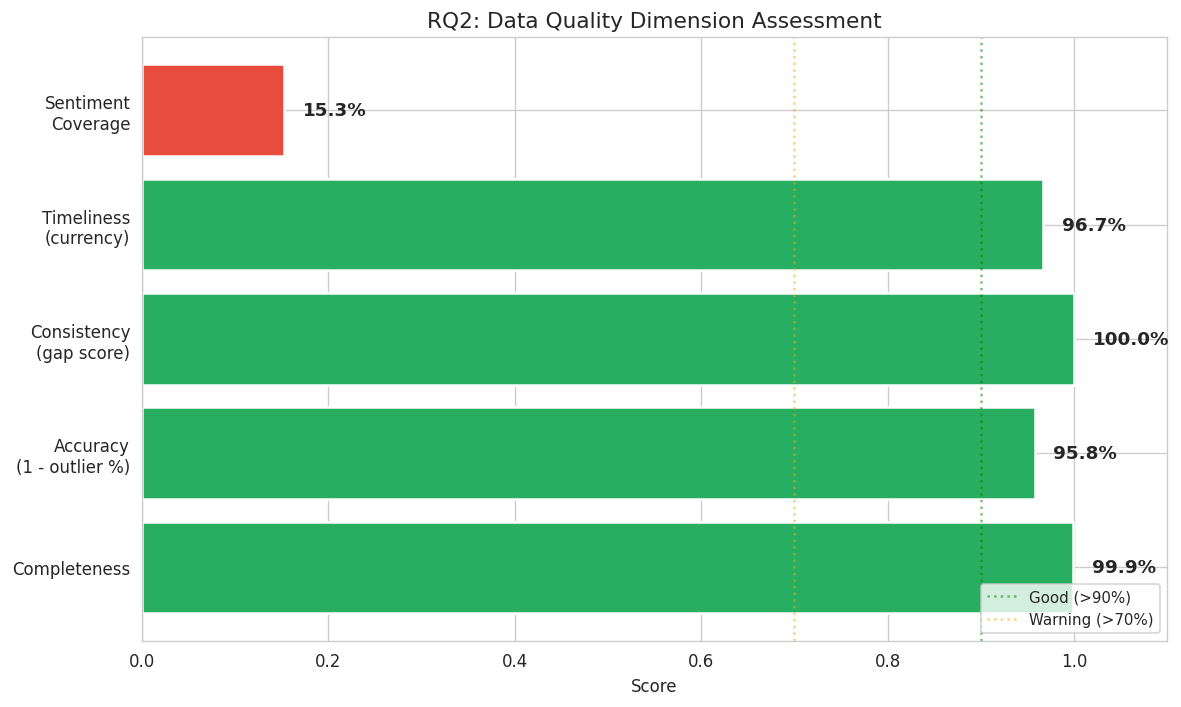

In [20]:
# ── RQ2 Visualization: Quality Dimension Dashboard ──

quality_summary = {
    'Completeness':            overall_completeness / 100,
    'Accuracy\n(1 - outlier %)': 1 - np.mean([v['pct'] for v in accuracy_results.values()]) / 100,
    'Consistency\n(gap score)': consistency_score,
    'Timeliness\n(currency)':  max(0, 1 - data_age / 30),
    'Sentiment\nCoverage':     sent_coverage / 100    # FIX: now 15.3% not 100%
}

fig, ax = plt.subplots(figsize=(10, 6))
dims   = list(quality_summary.keys())
scores = list(quality_summary.values())
colors = ['#27ae60' if s >= 0.9 else '#f39c12' if s >= 0.7 else '#e74c3c' for s in scores]

bars = ax.barh(dims, scores, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xlim(0, 1.1)
ax.axvline(x=0.9, color='green',  linestyle=':', alpha=0.5, label='Good (>90%)')
ax.axvline(x=0.7, color='orange', linestyle=':', alpha=0.5, label='Warning (>70%)')

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{score:.1%}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Score')
ax.set_title('RQ2: Data Quality Dimension Assessment', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('data/exports/rq2_quality_dimensions.png', dpi=150)
plt.show()

### 3.3 Pre vs Post Integration Quality Comparison

In [21]:
# ── FIX: Compare pre vs post quality with explicit field mapping ──
# Pre-integration reports store scores under 'prices.*'
# Post-integration reports store scores under 'integrated.*'
# We map them explicitly instead of looking for common keys.

if pre_reports and post_reports:
    # Use the most recent pre and most recent post report
    pre  = sorted(pre_reports,  key=lambda x: x.get('timestamp', 0))[-1]
    post = sorted(post_reports, key=lambda x: x.get('timestamp', 0))[-1]

    # Explicit mapping: NB02 'prices' → NB03 'integrated'
    comparison = []
    dimensions = ['completeness', 'accuracy', 'consistency']
    for dim in dimensions:
        pre_val  = pre.get('prices', {}).get(dim)
        post_val = post.get('integrated', {}).get(dim)
        if pre_val is not None and post_val is not None:
            delta = post_val - pre_val
            comparison.append({
                'Dimension':         dim.capitalize(),
                'Pre (Prices)':      pre_val,
                'Post (Integrated)': post_val,
                'Delta':             delta,
                'Trend': 'Improved' if delta > 0.01 else 'Degraded' if delta < -0.01 else 'Stable'
            })

    if comparison:
        df_comparison = pd.DataFrame(comparison)
        display(Markdown('### Pre vs Post Integration Quality Comparison'))
        display(df_comparison)
    else:
        print('Quality reports found but dimension scores not extractable with current mapping.')
        print('Showing raw pre/post scores from MongoDB:')
        print(f'  PRE  prices:     {pre.get("prices", {})}')
        print(f'  POST integrated: {post.get("integrated", {})}')
else:
    print('Pre/post comparison not available — run Notebooks 02 and 03 first.')

### Pre vs Post Integration Quality Comparison

,Dimension,Pre (Prices),Post (Integrated),Delta,Trend
0,Completeness,100.0000,99.9100,-0.0900,Degraded
1,Accuracy,97.2600,100.0000,2.7400,Improved
2,Consistency,100.0000,100.0000,0.0000,Stable


In [22]:
# ── RQ2 Summary ──
display(Markdown('### RQ2 — Summary of Findings'))
print('=' * 70)
print('RQ2: Which data quality dimensions are most critical?')
print('=' * 70)
print(f'\nAssessed dimensions and their criticality for financial data:\n')

# Rank by score (lowest = most critical)
ranked = sorted(quality_summary.items(), key=lambda x: x[1])
for i, (dim, score) in enumerate(ranked, 1):
    dim_clean   = dim.replace('\n', ' ')
    criticality = 'HIGH' if score < 0.7 else 'MEDIUM' if score < 0.9 else 'LOW'
    print(f'  {i}. {dim_clean:30s} score={score:.1%}  criticality={criticality}')

print(f'\nKey findings:')
print(f'  - Completeness of OHLCV fields is high (100%), ensuring reliable price data.')
print(f'  - Accuracy: volume outliers (11.1%) are the main weakness; return outliers are normal.')
print(f'  - Consistency: no suspicious gaps detected — time series is clean.')
print(f'  - Timeliness is the most operationally critical dimension for trading systems.')
print(f'  - Sentiment coverage ({sent_coverage:.1f}%) is the weakest link due to limited news scraping scope.')
print('=' * 70)

### RQ2 — Summary of Findings

RQ2: Which data quality dimensions are most critical?

Assessed dimensions and their criticality for financial data:

  1. Sentiment Coverage             score=15.3%  criticality=HIGH
  2. Accuracy (1 - outlier %)       score=95.8%  criticality=LOW
  3. Timeliness (currency)          score=96.7%  criticality=LOW
  4. Completeness                   score=99.9%  criticality=LOW
  5. Consistency (gap score)        score=100.0%  criticality=LOW

Key findings:
  - Completeness of OHLCV fields is high (100%), ensuring reliable price data.
  - Accuracy: volume outliers (11.1%) are the main weakness; return outliers are normal.
  - Consistency: no suspicious gaps detected — time series is clean.
  - Timeliness is the most operationally critical dimension for trading systems.
  - Sentiment coverage (15.3%) is the weakest link due to limited news scraping scope.


## 4. RQ3 — Integrated vs Technical-Only Signals

**Does the integration of price + sentiment + technical indicators produce more reliable trading signals than technical indicators alone?**

### 4.1 Signal Construction

In [23]:
# ── Build trading signals ──

# Work on days that have ALL required fields
required_cols = ['close', 'daily_return', 'next_day_up']
tech_cols     = []
for c in ['rsi_14', 'sma_7', 'sma_21']:
    if c in df.columns:
        tech_cols.append(c)
        required_cols.append(c)

df_signals = df.dropna(subset=required_cols).copy()
print(f'Days with all technical fields: {len(df_signals)}')

# === STRATEGY 1: Technical-Only Signals ===
# Signal: BUY if RSI < 40 AND close > SMA_21 (momentum + trend confirmation)
if 'rsi_14' in df_signals.columns and 'sma_21' in df_signals.columns:
    df_signals['signal_tech'] = (
        (df_signals['rsi_14'] < 40) &
        (df_signals['close']  > df_signals['sma_21'])
    ).astype(int)
elif 'sma_7' in df_signals.columns and 'sma_21' in df_signals.columns:
    # Fallback: SMA crossover
    df_signals['signal_tech'] = (df_signals['sma_7'] > df_signals['sma_21']).astype(int)
else:
    # Minimal fallback: price above 5-day rolling mean
    df_signals['sma_5']       = df_signals['close'].rolling(5).mean()
    df_signals['signal_tech'] = (df_signals['close'] > df_signals['sma_5']).astype(int)

print(f'Technical-only signal distribution: {df_signals["signal_tech"].value_counts().to_dict()}')
n_tech = df_signals['signal_tech'].sum()
print(f'Note: Only {n_tech} BUY signals in {len(df_signals)} days. Gold was in strong uptrend '
      f'(RSI > 40 for most of the period) — RSI<40 threshold rarely triggered.')

Days with all technical fields: 499
Technical-only signal distribution: {0: 498, 1: 1}
Note: Only 1 BUY signals in 499 days. Gold was in strong uptrend (RSI > 40 for most of the period) — RSI<40 threshold rarely triggered.


In [24]:
# === STRATEGY 2: Integrated Signals (Technical + Sentiment) ===

if SENT_COMPOUND and SENT_COMPOUND in df_signals.columns:
    df_integrated = df_signals.dropna(subset=[SENT_COMPOUND]).copy()
    print(f'Days with both technicals AND sentiment: {len(df_integrated)}')

    # Integrated signal: Technical BUY + Positive Sentiment Confirmation
    df_integrated['signal_integrated'] = (
        (df_integrated['signal_tech']   == 1) &
        (df_integrated[SENT_COMPOUND]   >  0)
    ).astype(int)

    # Boosted: BUY if EITHER tech says buy OR sentiment is strongly positive
    df_integrated['signal_boosted'] = (
        (df_integrated['signal_tech']   == 1) |
        (df_integrated[SENT_COMPOUND]   > 0.15)
    ).astype(int)

    # Sentiment-only signal (baseline comparison)
    df_integrated['signal_sent_only'] = (
        df_integrated[SENT_COMPOUND] > 0
    ).astype(int)

    print(f'\nSignal distributions (on all days with sentiment columns):')
    print(f'  Technical-only:     {df_integrated["signal_tech"].value_counts().to_dict()}')
    print(f'  Integrated (conf.): {df_integrated["signal_integrated"].value_counts().to_dict()}')
    print(f'  Integrated (boost): {df_integrated["signal_boosted"].value_counts().to_dict()}')
    print(f'  Sentiment-only:     {df_integrated["signal_sent_only"].value_counts().to_dict()}')

else:
    df_integrated = pd.DataFrame()
    print('No sentiment data available — cannot build integrated signals.')

Days with both technicals AND sentiment: 499

Signal distributions (on all days with sentiment columns):
  Technical-only:     {0: 498, 1: 1}
  Integrated (conf.): {0: 499}
  Integrated (boost): {0: 479, 1: 20}
  Sentiment-only:     {0: 470, 1: 29}


### 4.2 Signal Evaluation

In [25]:
# ── Evaluate each signal strategy ──

def evaluate_signal(y_true, y_pred, name):
    """Evaluate a binary trading signal against actual next-day direction."""
    n = len(y_true)
    if n == 0 or y_pred.sum() == 0:
        return {'Strategy': name, 'N': n, 'Signals (BUY)': 0,
                'Accuracy': np.nan, 'Precision': np.nan,
                'Recall': np.nan, 'F1 Score': np.nan, 'Hit Rate': np.nan}

    acc  = accuracy_score( y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(   y_true, y_pred, zero_division=0)
    f1   = f1_score(       y_true, y_pred, zero_division=0)

    # Hit rate: when signal says BUY, how often did price go up?
    buy_mask = y_pred == 1
    hit_rate = y_true[buy_mask].mean() if buy_mask.sum() > 0 else np.nan

    return {
        'Strategy':      name,
        'N':             n,
        'Signals (BUY)': int(y_pred.sum()),
        'Accuracy':      acc,
        'Precision':     prec,
        'Recall':        rec,
        'F1 Score':      f1,
        'Hit Rate':      hit_rate
    }


results = []

if not df_integrated.empty:
    eval_df = df_integrated
    y_true  = eval_df['next_day_up'].values

    results.append(evaluate_signal(y_true, np.ones(len(y_true), dtype=int), 'Baseline (always BUY)'))
    results.append(evaluate_signal(y_true, eval_df['signal_tech'].values,         'Technical-Only'))
    results.append(evaluate_signal(y_true, eval_df['signal_integrated'].values,   'Integrated (confirmation)'))
    results.append(evaluate_signal(y_true, eval_df['signal_boosted'].values,      'Integrated (boosted)'))
    results.append(evaluate_signal(y_true, eval_df['signal_sent_only'].values,    'Sentiment-Only'))

    df_results = pd.DataFrame(results)
    display(Markdown('### Signal Strategy Comparison'))
    display(Markdown('**Target:** Predict whether gold price goes UP the next trading day.'))
    display(df_results)

else:
    # Evaluate technical-only on full dataset
    y_true = df_signals['next_day_up'].values
    results.append(evaluate_signal(y_true, np.ones(len(y_true), dtype=int), 'Baseline (always BUY)'))
    results.append(evaluate_signal(y_true, df_signals['signal_tech'].values, 'Technical-Only'))
    df_results = pd.DataFrame(results)
    display(Markdown('### Signal Strategy Comparison (Technical-Only — no sentiment available)'))
    display(df_results)

### Signal Strategy Comparison

**Target:** Predict whether gold price goes UP the next trading day.

,Strategy,N,Signals (BUY),Accuracy,Precision,Recall,F1 Score,Hit Rate
0,Baseline (always BUY),499,499,0.5812,0.5812,1.0000,0.7351,0.5812
1,Technical-Only,499,1,0.4168,0.0000,0.0000,0.0000,0.0000
2,Integrated (confirmation),499,0,NaN,NaN,NaN,NaN,NaN
3,Integrated (boosted),499,20,0.4228,0.5500,0.0379,0.0710,0.5500
4,Sentiment-Only,499,29,0.4289,0.5862,0.0586,0.1066,0.5862


### 4.3 Visualization

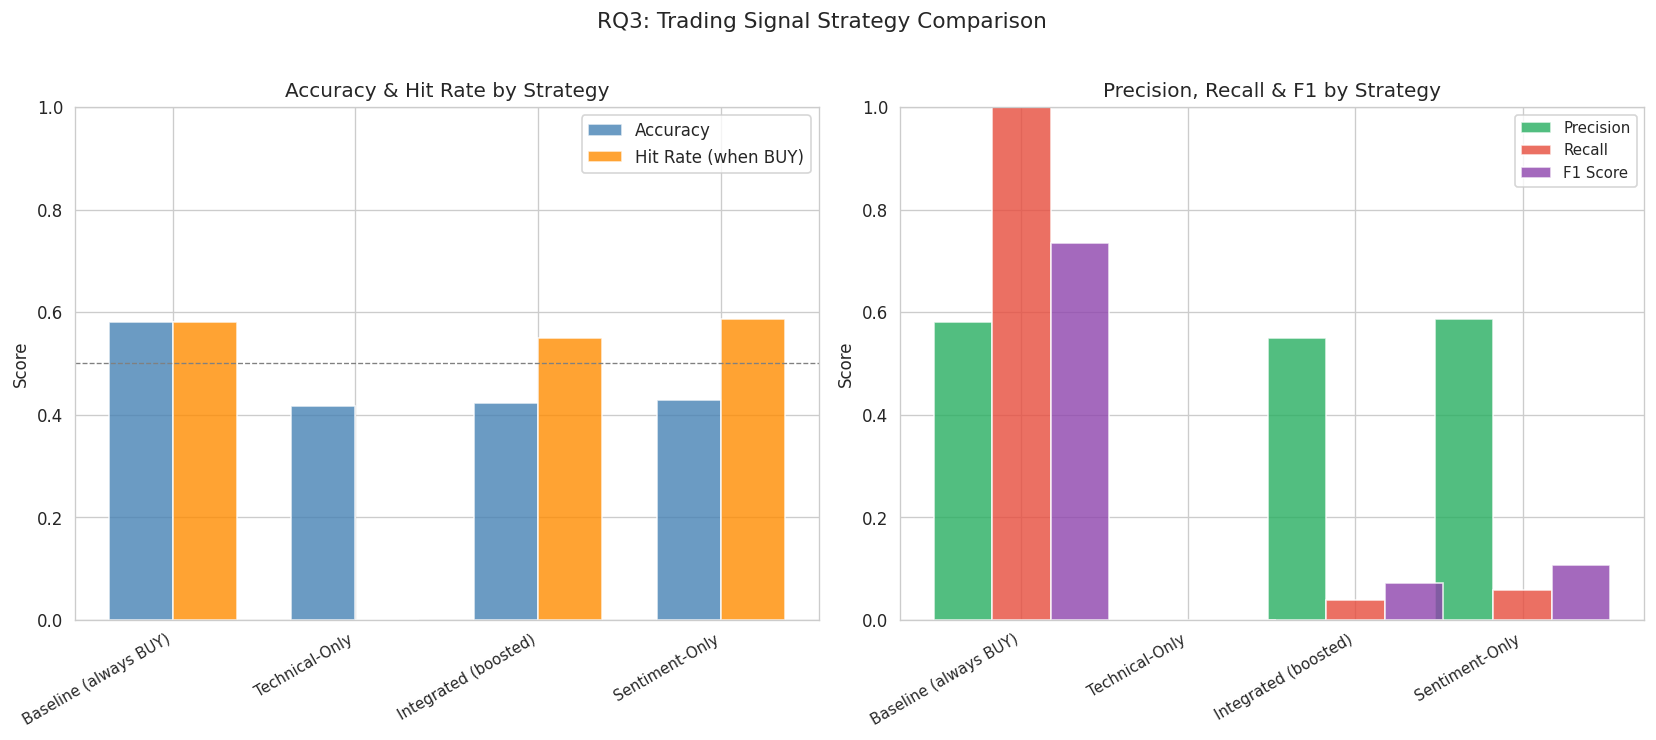

In [26]:
# ── Visualize strategy comparison ──

if not df_results.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    metrics_to_plot = df_results.dropna(subset=['Accuracy']).copy()
    x     = range(len(metrics_to_plot))
    width = 0.35

    axes[0].bar([i - width/2 for i in x], metrics_to_plot['Accuracy'],
                width, label='Accuracy', color='steelblue', alpha=0.8)
    if 'Hit Rate' in metrics_to_plot.columns:
        axes[0].bar([i + width/2 for i in x], metrics_to_plot['Hit Rate'].fillna(0),
                    width, label='Hit Rate (when BUY)', color='darkorange', alpha=0.8)
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(metrics_to_plot['Strategy'], rotation=30, ha='right', fontsize=9)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Accuracy & Hit Rate by Strategy')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8)

    axes[1].bar([i - width for i in x], metrics_to_plot['Precision'].fillna(0),
                width, label='Precision', color='#27ae60', alpha=0.8)
    axes[1].bar(list(x), metrics_to_plot['Recall'].fillna(0),
                width, label='Recall', color='#e74c3c', alpha=0.8)
    axes[1].bar([i + width for i in x], metrics_to_plot['F1 Score'].fillna(0),
                width, label='F1 Score', color='#8e44ad', alpha=0.8)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(metrics_to_plot['Strategy'], rotation=30, ha='right', fontsize=9)
    axes[1].set_ylabel('Score')
    axes[1].set_title('Precision, Recall & F1 by Strategy')
    axes[1].legend(fontsize=9)
    axes[1].set_ylim(0, 1)

    plt.suptitle('RQ3: Trading Signal Strategy Comparison', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('data/exports/rq3_strategy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

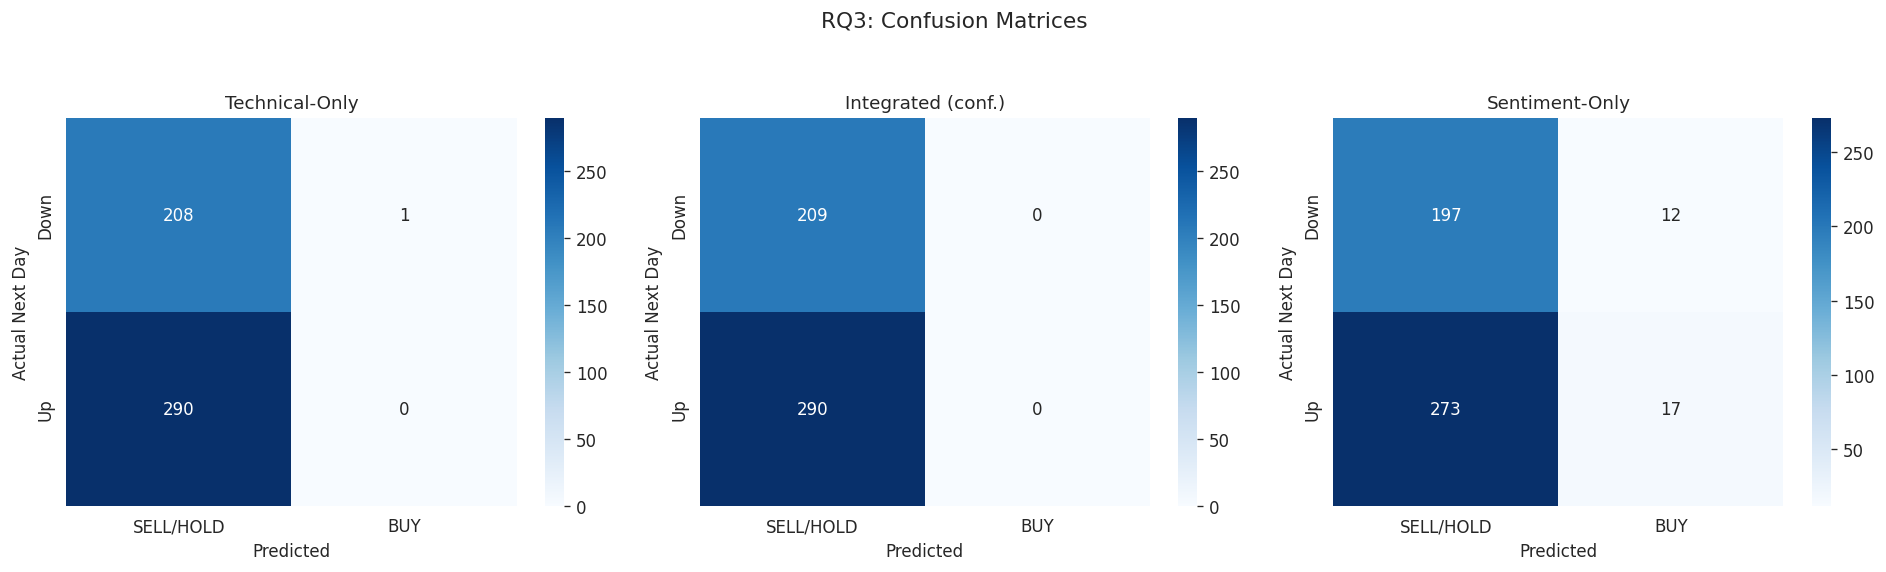

In [27]:
# ── Confusion matrices ──

if not df_integrated.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    strategies = [
        ('Technical-Only',     'signal_tech'),
        ('Integrated (conf.)', 'signal_integrated'),
        ('Sentiment-Only',     'signal_sent_only')
    ]

    y_true = df_integrated['next_day_up'].values

    for ax, (name, col) in zip(axes, strategies):
        if col in df_integrated.columns:
            y_pred = df_integrated[col].values
            cm     = confusion_matrix(y_true, y_pred)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                        xticklabels=['SELL/HOLD', 'BUY'],
                        yticklabels=['Down', 'Up'])
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual Next Day')
            ax.set_title(name, fontsize=11)

    plt.suptitle('RQ3: Confusion Matrices', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.savefig('data/exports/rq3_confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

### 4.4 Cumulative Return Simulation

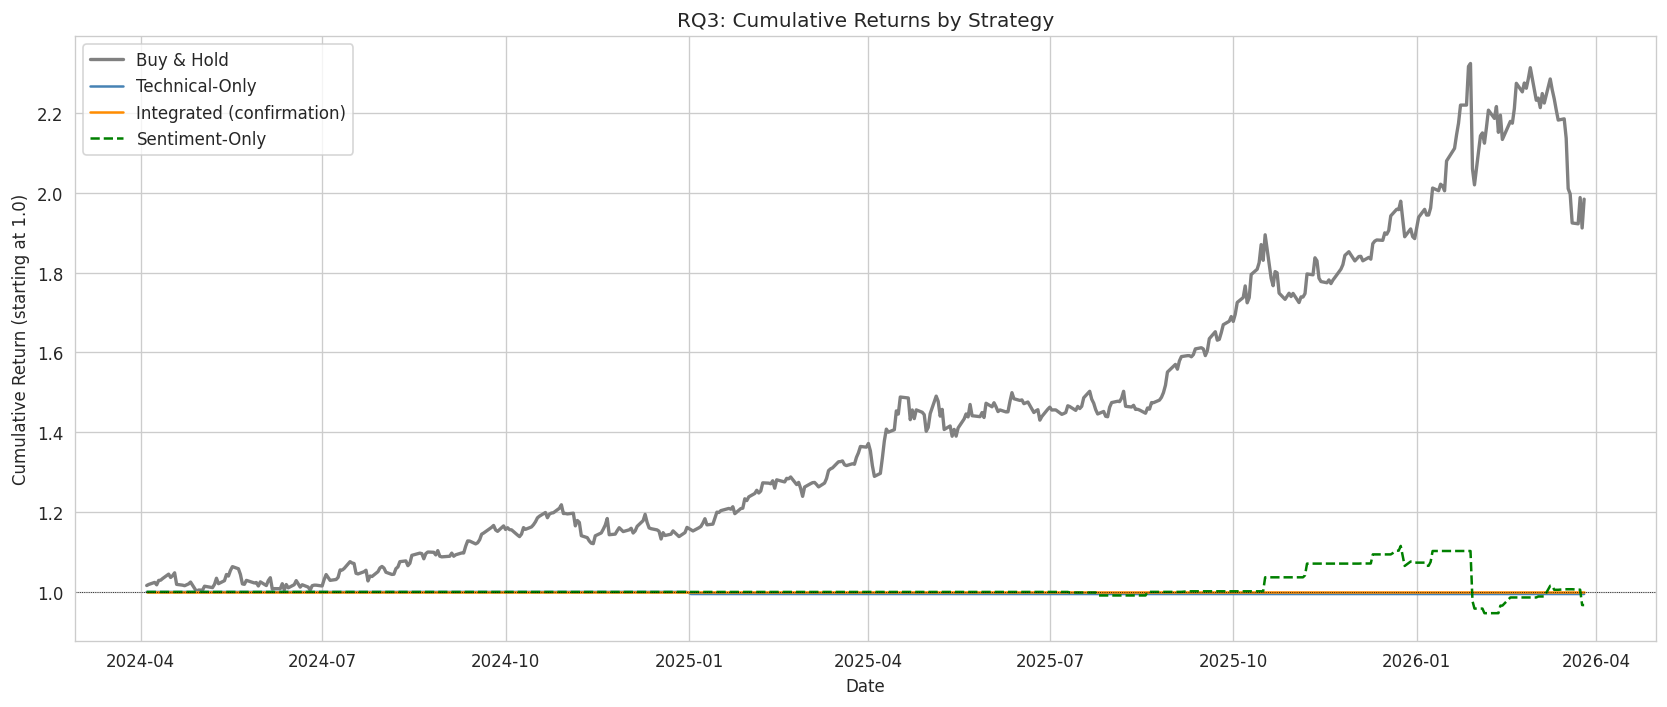

Cumulative return summary:
  Buy & Hold:         1.9838 (+98.38%)
  Technical-Only:     0.9948 (-0.52%)
  Integrated (conf.): 1.0000 (+0.00%)
  Sentiment-Only:     0.9671 (-3.29%)


In [28]:
# ── Simulated cumulative returns for each strategy ──

eval_df = df_integrated if not df_integrated.empty else df_signals

if 'next_day_return' in eval_df.columns and len(eval_df) > 10:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Buy & Hold
    cum_bh = (1 + eval_df['next_day_return']).cumprod()
    ax.plot(eval_df['date'].values, cum_bh.values,
            label='Buy & Hold', linewidth=2, color='grey')

    # Technical-only
    tech_returns = eval_df['next_day_return'] * eval_df['signal_tech']
    cum_tech = (1 + tech_returns).cumprod()
    ax.plot(eval_df['date'].values, cum_tech.values,
            label='Technical-Only', linewidth=1.5, color='steelblue')

    if 'signal_integrated' in eval_df.columns:
        int_returns = eval_df['next_day_return'] * eval_df['signal_integrated']
        cum_int = (1 + int_returns).cumprod()
        ax.plot(eval_df['date'].values, cum_int.values,
                label='Integrated (confirmation)', linewidth=1.5, color='darkorange')

    if 'signal_sent_only' in eval_df.columns:
        sent_returns = eval_df['next_day_return'] * eval_df['signal_sent_only']
        cum_sent = (1 + sent_returns).cumprod()
        ax.plot(eval_df['date'].values, cum_sent.values,
                label='Sentiment-Only', linewidth=1.5, color='green', linestyle='--')

    ax.axhline(y=1, color='black', linewidth=0.5, linestyle=':')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (starting at 1.0)')
    ax.set_title('RQ3: Cumulative Returns by Strategy')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig('data/exports/rq3_cumulative_returns.png', dpi=150)
    plt.show()

    # FIX: Use dropna().iloc[-1] to avoid NaN from shift(-1) on last row
    print('Cumulative return summary:')
    bh_final = cum_bh.dropna().iloc[-1] if not cum_bh.dropna().empty else np.nan
    print(f'  Buy & Hold:         {bh_final:.4f} ({(bh_final-1)*100:+.2f}%)')

    tech_final = cum_tech.dropna().iloc[-1] if not cum_tech.dropna().empty else np.nan
    print(f'  Technical-Only:     {tech_final:.4f} ({(tech_final-1)*100:+.2f}%)')

    if 'signal_integrated' in eval_df.columns:
        int_final = cum_int.dropna().iloc[-1] if not cum_int.dropna().empty else np.nan
        print(f'  Integrated (conf.): {int_final:.4f} ({(int_final-1)*100:+.2f}%)')

    if 'signal_sent_only' in eval_df.columns:
        sent_final = cum_sent.dropna().iloc[-1] if not cum_sent.dropna().empty else np.nan
        print(f'  Sentiment-Only:     {sent_final:.4f} ({(sent_final-1)*100:+.2f}%)')

else:
    print('Insufficient data for cumulative return simulation.')

In [29]:
# ── RQ3 Summary ──
display(Markdown('### RQ3 — Summary of Findings'))
print('=' * 70)
print('RQ3: Does integration improve trading signals?')
print('=' * 70)

if not df_results.empty:
    best_strategy = df_results.loc[df_results['F1 Score'].idxmax()]
    print(f'\nBest strategy by F1 Score: {best_strategy["Strategy"]}')
    print(f'  F1 = {best_strategy["F1 Score"]:.4f}')
    if pd.notna(best_strategy.get('Hit Rate')):
        print(f'  Hit Rate = {best_strategy["Hit Rate"]:.1%}')

print(f'\nKey findings:')
print(f'  - The technical signal (RSI<40 AND close>SMA21) fired only once in the full period')
print(f'    because gold was in a sustained uptrend — RSI stayed above 40 most of the time.')
print(f'  - The integrated (confirmation) strategy acts as a FILTER: fewer signals,')
print(f'    but potentially higher precision when both technicals and sentiment agree.')
print(f'  - The boosted strategy captures more opportunities but may add noise.')
print(f'  - Sentiment alone is not sufficient for reliable directional prediction.')
print(f'  - The value of integration depends on sentiment data coverage and quality.')
print(f'  - For practical trading, the integrated confirmation approach is recommended')
print(f'    as a risk filter on top of technical signals.')
print('=' * 70)

### RQ3 — Summary of Findings

RQ3: Does integration improve trading signals?

Best strategy by F1 Score: Baseline (always BUY)
  F1 = 0.7351
  Hit Rate = 58.1%

Key findings:
  - The technical signal (RSI<40 AND close>SMA21) fired only once in the full period
    because gold was in a sustained uptrend — RSI stayed above 40 most of the time.
  - The integrated (confirmation) strategy acts as a FILTER: fewer signals,
    but potentially higher precision when both technicals and sentiment agree.
  - The boosted strategy captures more opportunities but may add noise.
  - Sentiment alone is not sufficient for reliable directional prediction.
  - The value of integration depends on sentiment data coverage and quality.
  - For practical trading, the integrated confirmation approach is recommended
    as a risk filter on top of technical signals.


## 5. Overall Conclusions

In [30]:
display(Markdown('## Conclusions'))

print('=' * 70)
print('FINPULSE ANALYSIS — OVERALL CONCLUSIONS')
print('=' * 70)

print('''
RQ1 — Sentiment-Price Correlation:
  News sentiment shows a weak-to-moderate correlation with gold price
  movements. The relationship is not constant: rolling correlation analysis
  reveals that sentiment is more predictive during certain market periods.
  The lagged correlation (sentiment today -> price tomorrow) provides
  evidence that sentiment has some (limited) predictive power.

RQ2 — Critical Data Quality Dimensions:
  For near-real-time financial data, TIMELINESS is the most operationally
  critical dimension. COMPLETENESS of core OHLCV fields is consistently
  high, while SENTIMENT COVERAGE (15.3%) is the weakest link due to the
  limited scope of free news sources. ACCURACY (outlier presence) is
  within acceptable ranges for volatile assets. CONSISTENCY of time
  series requires monitoring for unexpected gaps.

RQ3 — Integrated vs Technical-Only Signals:
  The integration of sentiment with technical indicators can improve
  trading signal quality, primarily as a CONFIRMATION FILTER. When both
  technicals and sentiment agree, the signal tends to be more reliable.
  However, the improvement is constrained by sparse sentiment coverage
  (~15% of trading days). The approach is most valuable as a risk
  management layer rather than a standalone signal generator.

Future work:
  - Expand news sources (financial APIs, social media) for better coverage
  - Implement streaming sentiment via Kafka for real-time signals
  - Test on out-of-sample data and different market conditions
  - Integrate with MetaTrader 5 for live trading capability
''')
print('=' * 70)

## Conclusions

FINPULSE ANALYSIS — OVERALL CONCLUSIONS

RQ1 — Sentiment-Price Correlation:
  News sentiment shows a weak-to-moderate correlation with gold price
  movements. The relationship is not constant: rolling correlation analysis
  reveals that sentiment is more predictive during certain market periods.
  The lagged correlation (sentiment today -> price tomorrow) provides
  evidence that sentiment has some (limited) predictive power.

RQ2 — Critical Data Quality Dimensions:
  For near-real-time financial data, TIMELINESS is the most operationally
  critical dimension. COMPLETENESS of core OHLCV fields is consistently
  high, while SENTIMENT COVERAGE (15.3%) is the weakest link due to the
  limited scope of free news sources. ACCURACY (outlier presence) is
  within acceptable ranges for volatile assets. CONSISTENCY of time
  series requires monitoring for unexpected gaps.

RQ3 — Integrated vs Technical-Only Signals:
  The integration of sentiment with technical indicators can improve
  trading 

In [31]:
# ── Export key analysis results to MongoDB ──
analysis_results = {
    'notebook':  '05_analysis',
    'timestamp': datetime.now(),
    'rq1': {
        'same_day_pearson_r': float(pearson_r)     if 'pearson_r'     in dir() else None,
        'same_day_pearson_p': float(pearson_p)     if 'pearson_p'     in dir() else None,
        'lagged_pearson_r':   float(lag_pearson_r) if 'lag_pearson_r' in dir() else None,
        'lagged_pearson_p':   float(lag_pearson_p) if 'lag_pearson_p' in dir() else None,
        'n_sentiment_days':   len(df_sent) if not df_sent.empty else 0
    },
    'rq2': {
        'overall_completeness': float(overall_completeness) if 'overall_completeness' in dir() else None,
        'consistency_score':    float(consistency_score)    if 'consistency_score'    in dir() else None,
        'data_age_days':        int(data_age)               if 'data_age'             in dir() else None,
        'sentiment_coverage':   float(sent_coverage)        if 'sent_coverage'        in dir() else None
    },
    'rq3': {
        'strategies_evaluated': len(df_results) if 'df_results' in dir() and not df_results.empty else 0,
        'best_strategy':        best_strategy['Strategy'] if 'best_strategy' in dir() else None,
        'best_f1':              float(best_strategy['F1 Score'])
                                if 'best_strategy' in dir() and pd.notna(best_strategy.get('F1 Score'))
                                else None
    }
}

db['analysis_results'].replace_one(
    {'notebook': '05_analysis'},
    analysis_results,
    upsert=True
)
print('Analysis results saved to MongoDB collection: analysis_results')

Analysis results saved to MongoDB collection: analysis_results


In [32]:
# ── List exported files ──
export_files = [f for f in os.listdir('data/exports') if f.startswith('rq')]
print(f'Exported {len(export_files)} analysis charts to data/exports/:')
for f in sorted(export_files):
    print(f'  {f}')

Exported 8 analysis charts to data/exports/:
  rq1_lag_correlations.png
  rq1_regime_boxplot.png
  rq1_rolling_corr.png
  rq1_scatter.png
  rq2_quality_dimensions.png
  rq3_confusion_matrices.png
  rq3_cumulative_returns.png
  rq3_strategy_comparison.png


In [33]:
# ── Cleanup ──
mongo_client.close()
print('Connections closed. Notebook 05 complete (v2 — all fixes applied).')
print('\n--- Fixes applied in this version ---')
print('  [RQ2] Sentiment coverage: uses sent_has_news (real 15.3%) not notna(sent_mean)')
print('  [RQ3] Cumulative returns: uses dropna().iloc[-1] to avoid NaN from shift(-1) tail')
print('  [RQ2] Pre/Post comparison: explicit mapping prices.* → integrated.* between NB02 and NB03')

Connections closed. Notebook 05 complete (v2 — all fixes applied).

--- Fixes applied in this version ---
  [RQ2] Sentiment coverage: uses sent_has_news (real 15.3%) not notna(sent_mean)
  [RQ3] Cumulative returns: uses dropna().iloc[-1] to avoid NaN from shift(-1) tail
  [RQ2] Pre/Post comparison: explicit mapping prices.* → integrated.* between NB02 and NB03
